<a href="https://colab.research.google.com/github/damnhuquynhvn-oss/thuchanhdeeplearning/blob/main/Lab03_Ph%E1%BA%A7n%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [2]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [3]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


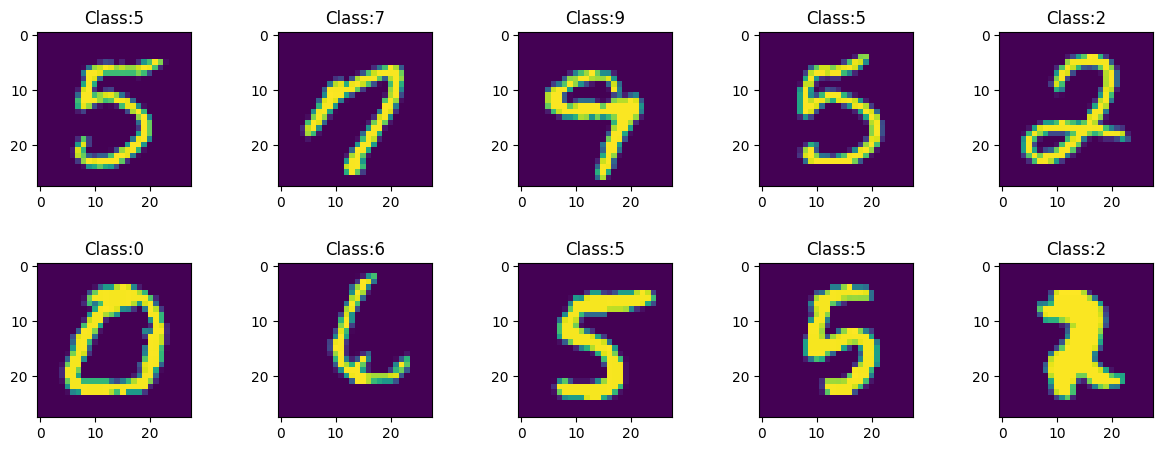

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [5]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation="softmax"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.8492 - loss: 0.5789 - val_accuracy: 0.9355 - val_loss: 0.2247
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9592 - loss: 0.1419 - val_accuracy: 0.9570 - val_loss: 0.1415
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9724 - loss: 0.0954 - val_accuracy: 0.9660 - val_loss: 0.1081
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.9767 - loss: 0.0759 - val_accuracy: 0.9695 - val_loss: 0.1009
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9813 - loss: 0.0600 - val_accuracy: 0.9730 - val_loss: 0.0804
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.9824 - loss: 0.0539 - val_accuracy: 0.9780 - val_loss: 0.0785
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9863 - loss: 0.0455 - val_accuracy: 0.9760 - val_loss: 0.0901
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.9879 - loss: 0.0389 -

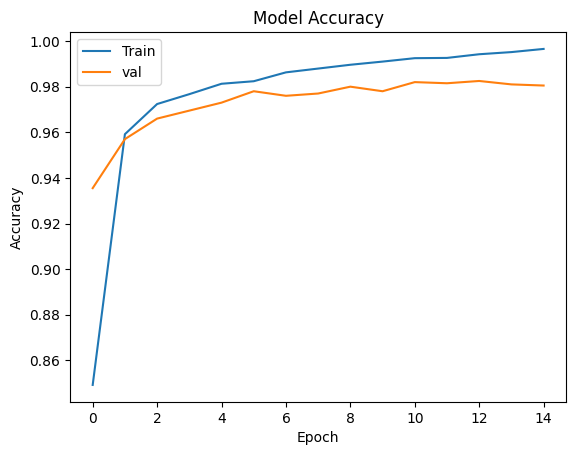

In [7]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

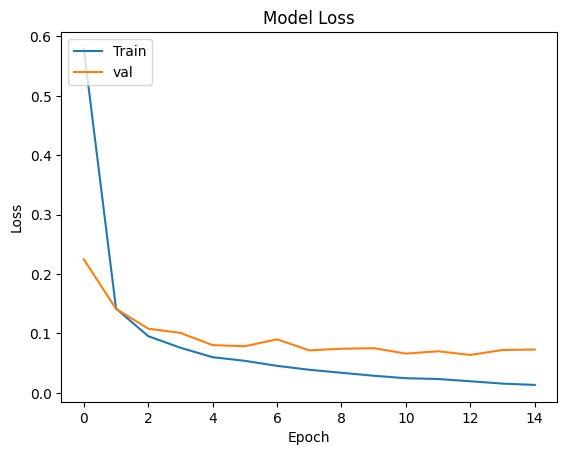

In [8]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'val'], loc='upper left')
plt.show()

In [9]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9834 - loss: 0.0557
Test loss: 0.055745791643857956
Test accuracy: 0.9833983182907104


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[1.9770987e-06 5.4769171e-05 9.9994326e-01 1.0164194e-10 4.8454631e-20
  3.8666383e-14 4.8918402e-08 2.0907473e-17 1.0404898e-09 5.4705377e-20]]
2 2


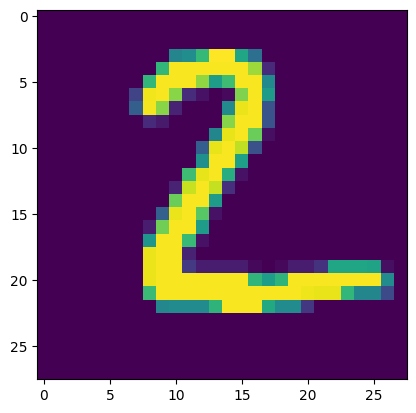

In [10]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))

plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[1.4900949e-07 9.9996531e-01 4.8323141e-06 4.7155094e-08 1.4552759e-05
  5.9007366e-08 1.6660618e-07 1.3939120e-05 1.0379534e-06 5.9065779e-09]]
1 1


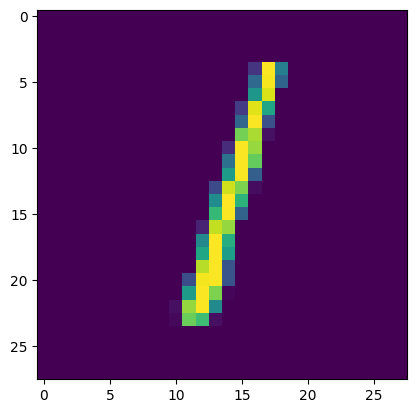

In [11]:
model.save_weights('cnn.weights.h5')
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')
predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))

plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


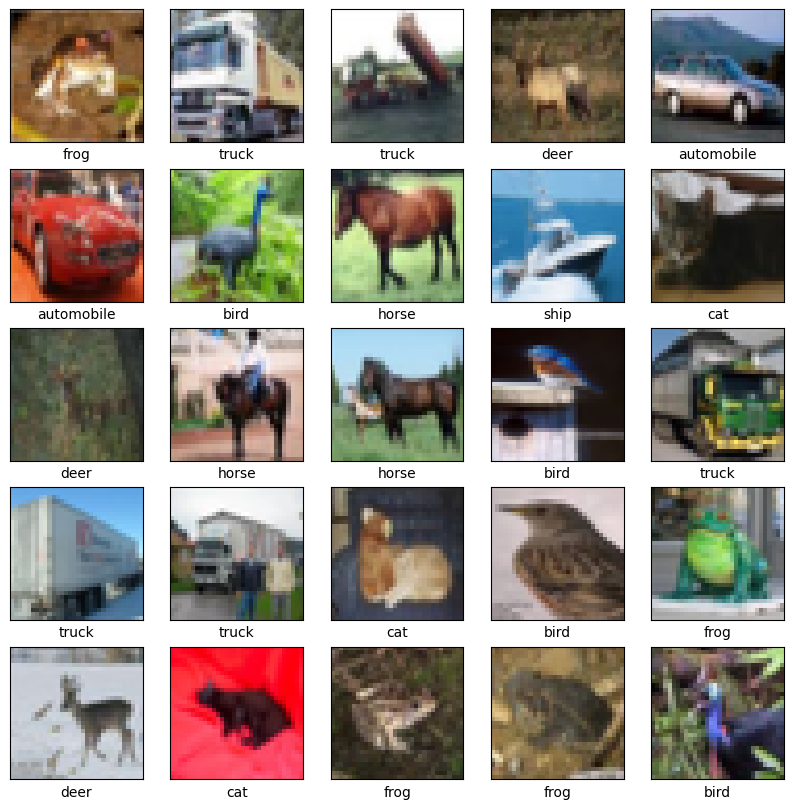

In [12]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [13]:
model_cifar = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

model_cifar.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model_cifar.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model_cifar.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4518 - loss: 1.5052 - val_accuracy: 0.5197 - val_loss: 1.3018
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5975 - loss: 1.1378 - val_accuracy: 0.6140 - val_loss: 1.0938
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6534 - loss: 0.9852 - val_accuracy: 0.6524 - val_loss: 0.9763
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.6897 - loss: 0.8868 - val_accuracy: 0.6862 - val_loss: 0.9062
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7148 - loss: 0.8132 - val_accuracy: 0.6727 - val_loss: 0.9405
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.7324 - loss: 0.7642 - val_accuracy: 0.7060 - val_loss: 0.8685
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7508 - loss: 0.7084 - val_accuracy: 0.6967 - val_loss: 0.8915
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7652 -

313/313 - 5s - 15ms/step - accuracy: 0.7163 - loss: 0.8511

Độ chính xác trên tập kiểm tra: 0.7163000106811523


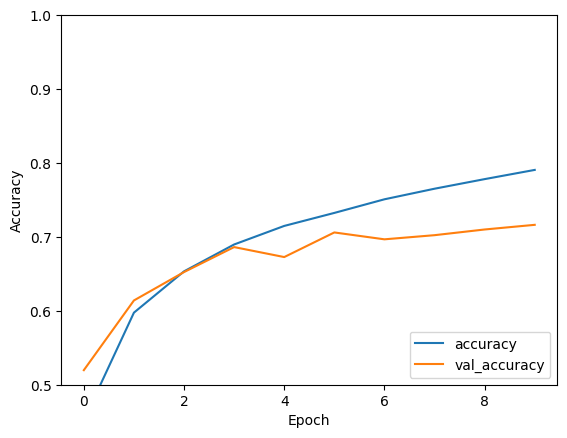

In [15]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model_cifar.evaluate(test_images,  test_labels, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm tra: {test_acc}')